In [9]:
# backend/aiml_models/agent_teams/agent_tailored_cover_letter/src/notebook/playground.ipynb
import sys
import os
from pathlib import Path

# Dynamically add project root to sys.path so 'src' package is importable
from pathlib import Path
NOTEBOOK_DIR = Path.cwd()                   # e.g. .../agent_tailored_cover_letter/src/notebook
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent   # .../agent_tailored_cover_letter
for folder in [str(PROJECT_ROOT)] + [str(p) for p in PROJECT_ROOT.rglob('*') if p.is_dir()]:
    if folder not in sys.path:
        sys.path.insert(0, folder)

# Debug: verify
print("sys.path:", sys.path)

from typing import TypedDict, List, Annotated, Dict, Any, Optional
from langgraph.graph.message import add_messages, AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from pprint import pprint
import uuid
import logging


# Import the required module after fixing the path issue
# from src.core.graph_master.graph_nodes.node_generate_vacancy_analysis import generate_vacancy_analysis
# from src.core.graph_master.graph_nodes.node_get_skills import get_skills
# from src.core.graph_master.graph_nodes.node_generate_cover_letter import generate_cover_letter
# from src.core.editorial.graph_nodes.node_user_in_the_loop import user_in_the_loop
# from src.core.editorial.graph_nodes.node_validate_and_correct_editorial import validate_and_correct_editorial
# from src.core.editorial.graph_nodes.node_decide_editorial_correction import decide_editorial_next_step



class testState(TypedDict):
    # init values
    messages: Annotated[List[AnyMessage], add_messages]
    job_description: str
    iterations: int
    unique_user_input: str  # this is the user input that is unique for each flow run, e.g. a user note or specific comments for the generation of a cover letter
    # values populated during the flow
    
    #node_get_data
    skills: list[str]
    words_to_avoid: List[str]
    sentences_to_avoid: List[str]
    best_match_template_cover_letter: Optional[str]
    agent_trace: Optional[List[str]]
    cv: str # not implemetned yet
    
    #node_generate_vacancy_analysis
    analysis_output: Optional[Dict[str, Any]]
    matching_skills: Optional[Dict[str, bool]]
    cover_letter_output: Optional[Dict[str, Any]]
    language_detected: str
    cover_letter_revision_history: Optional[List[Dict[str, Any]]]

    #node_audit_cover_letter
    editorial_violations_log: Optional[List[str]]

user_note = """this is a test text for flow"""

dummy_job_description = """
About the job
Are you motivated by making a difference and being part of a team of ambitious talents with diverse backgrounds? Would you like to drive complex improvement projects across our global manufacturing network? Do you have Operational Excellence background?
If so, you could be our new Project Manager. Apply today and join us for a life-changing ca-reer!
The position
As a Project Manager, you will be part of maximising capacities across our Global Aseptic Man-ufacturing network. You will be part of capacity improvement projects including building the project strategy and scope, as well as developing and implementing solutions. All of this you will do in close collaboration with your team of highly specialized OPEX experts and our manu-facturing sites, who will be responsible for sustaining the impact of the improvements.
Your responsibilities will include driving workstreams/projects in manufacturing and to:
Drive capacity improvements across our current fleet of aseptic manufacturing lines.
Lead and facilitate sessions with senior stakeholders to discuss and align on perfor-mance metrics and strategic initiatives.
Collaborate with stakeholders across the organization, including global experts, local site management and operational employees as well as local experts.
The position is based in Copenhagen Region, Denmark, however you can expect up to 50% travel per year to our global manufacturing sites in the US, Italy, Brazil, France, China, Denmark as well as new manufacturing sites entering our global network.
Qualifications
To succeed in this role, you have:
A MSc Degree in economics, business administration, engineering, science, medical fields or similar.
+3 years of work experience with operational excellence, preferably in manufacturing, experience from a management consultancy or a pharmaceutical company is an ad-vantage. Minimum of 1 years of independent Project Manager experience within com-plex transformation projects.
Excellent analytical, quantitative and qualitative problem-solving skills combined with track-record of driving strategic processes.
Professional proficiency in English.
On a personal level, you are ambitious, challenge-seeking and result-oriented. You have great interpersonal skills that allow you to communicate complex information clearly (both verbally and in writing). Moreover, you are motivated and ready to drive change at all levels of the or-ganisation.
About The Department
The department is a newly established organizational unit called Aseptic Manufacturing Engi-neering (AME). With more than 150 colleagues, we play a key role in accelerating a major transformation to improve performance across a global network of factories to meet the need of the increasing number of people living with diabetes and obesity. AME is an organizational unit in Aseptic Manufacturing (AM), which is the largest production area in Novo Nordisk with more than 10,000 employees.
You will be part of a newly established team with the responsibility of driving complex im-provements projects based on operational excellence principles across our aseptic production network worldwide. The team functions as an in-house consultancy and will drive a broad range of high-profile improvement projects across our strategic aseptic manufacturing sites. Within the unit there are people who work with digital and analytics initiatives which enables us to fuel our operational excellence projects with even more compute power as well as digital tools to drive the business forward.
Our projects provide exposure to Heads of manufacturing for all team members, and we de-velop our talents by continuously investing in both personal and professional development and strive to offer a steep learning curve.
Working at Novo Nordisk 
Novo Nordisk is its people. We know that life is anything but linear and balancing what is im-portant at different stages of our career is never easy. That’s why we make room for diverse life situations, always putting people first. We value our employees for the unique skills they bring to the table, and we work continuously on bringing out the best in them. Working at No-vo Nordisk is working toward something bigger than ourselves, and it’s a collective effort.
"""
dummy_unique_user_input = "important to not MIX up previous experiences from the CV with one another"

initial_state : testState = testState(
    messages=["user", user_note],
    job_description=dummy_job_description,
    unique_user_input = dummy_unique_user_input,
    max_iterations=1, # consider if a user can set this to a higher value.
    iterations=0,
)

sys.path: ['/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/cover_letter/components/__pycache__', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/cover_letter/graph_nodes/__pycache__', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/cover_letter/components', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/cover_letter/graph_nodes', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/cover_letter/__pycache__', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/graph_master/graph_nodes/__pycache__', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/graph_master/graph_utility_nodes', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/graph_master/graph_nodes', '/home/mangabat/projects/portofolio/agent_tailored_cover_letter/src/core/graph_master/__pycache__', '/home/mangabat/projects/portofolio/agent_tailo

In [10]:
import logging
import httpx
from typing import List, Dict, Optional, Literal
from datetime import datetime
from langchain_core.documents import Document
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import SearchParams, ScoredPoint

from src.config.service_settings import AgentSettings
from src.config.config_db_connections import QdrantConnection
from src.utils.trace_logger import append_node_trace
 
def node_get_data(state: Dict) -> Dict:
    """
    Unified data-fetch node for LangGraph flow.
    
    Purpose:
        Fetch user-defined word/sentence/skill corrections, semantic document from Qdrant,
        and placeholder CV content.

    Capabilities:
        - Calls corrections API for taboo words, overused sentences, and relevant skills
        - Performs semantic search in Qdrant using a fixed test query
        - Returns a structured document and CV placeholder
        - Appends agent trace via reusable utility

    Reasoning:
        Separated from LLM flow to isolate I/O-heavy preprocessing steps. 
        Trace logging delegated to shared utility to maintain consistency across nodes.
    """
    logging.info("Node: node_get_data.py - Starting unified data fetch")
    print("!!NODE!!: node_get_data.py - Starting unified data fetch\n")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    # --- Corrections API fetch ---
    settings = AgentSettings()
    corrections_url: str = f"http://{settings.CORRECTION_API_URL}/corrections"

    def fetch_texts(correction_type: Literal["word", "sentence", "skill"]) -> List[str]:
        logging.info(f"Fetching corrections from: {corrections_url} [{correction_type=}]")
        response = httpx.get(corrections_url, params={"correction_type": correction_type})
        response.raise_for_status()
        return [item["text"] for item in response.json() if "text" in item]

    state["words_to_avoid"] = fetch_texts("word")
    state["sentences_to_avoid"] = fetch_texts("sentence")
    state["skills"] = fetch_texts("skill")

    # --- Qdrant Semantic Search ---
    embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
    qdrant_connection = QdrantConnection()
    client: QdrantClient = qdrant_connection.client
    collection_name: str = qdrant_connection.default_collection

    vector: List[float] = embedding_model.encode(state["job_description"], normalize_embeddings=False).tolist()

    search_results: List[ScoredPoint] = client.query_points(
        collection_name=collection_name,
        query=vector,
        limit=1,
        with_payload=True,
        search_params=SearchParams(hnsw_ef=128)
    )

    # Print embedding as text

    search_results_text = search_results.points[0].payload['text']

    print(f"DOCUMENT:{search_results_text}\n")
    # --- CV Placeholder ---
    cv_text: Optional[str] = """Profil
Jeg har en baggrund i Data Science og IT-økonomi og trives bedst dér, hvor analyse, teknologi, forretning og mennesket mødes. Min tilgang er praktisk og nysgerrig: Jeg finder noget spændende, dykker ned i teorien – og bygger eller tester det bagefter. Uanset om det handler om machine learning, automatisering, vektorbaseret søgning eller datastrukturer, arbejder jeg dedikeret og resultatorienteret med fokus på, hvad der også giver mening om 2–5 år.
Jeg nyder kompleksitet – især når det gælder, hvordan vi gør AI/ML-løsninger mere gennemsigtige og ansvarlige. Og når hjernen skal lufte ud, sker det gerne med kitesurfing, snowboard eller anden fysisk aktivitet.________________________________________
Uddannelse
MSc Data Science – ICT, Syddansk Universitet (2023)
•	Speciale: "A study of Natural Language Processing applied to market research"
o	Semiautomatisk PEST-analyse med vektorbaseret søgning og entity recognition
•	Fokus: Multivariat statistik, Applied Machine Learning,  Software Engineering, Visualisering

Professionsbachelor i Økonomi og IT, Erhvervsakademi Aarhus (2021)
•	Bachelorprojekt: “EnviroProcess Foundation of IT ”, Enterprise Architecture as digital strategy
•	Frivilligt project: "Amazon’s entry into the Danish market – e-commerce impact analysis"
•	Fokus: Strategi, digitalisering, finansiering, enterprise architecture og forretningsanalyse

International Butler Academy, 2018
European Bartender School, 2011
________________________________________
Erhvervserfaring
Projektleder (Kontrakt) – EnviroProcess Denmark A/S (2023 – 2024)
•	Ansvarlig for opførelse og montering af tekniske anlæg til svømmehal og wellness
•	Deltog selv i den praktiske udførelse på byggepladsen sammen med faggrupper
•	Koordinerede med byggeledelse, el- og VVS-installatører
•	Stod for kvalitetssikring, dokumentation og daglig fremdrift
Projektleder – EnviroProcess (2017 – 2021)
•	Ledelse af multidisciplinære teams og interessenthåndtering på tværs af interne og eksterne parter
•	Implementerede en hybrid Scrum-model til at styre opbygning og fremdrift af byggeriprojekter
•	Planlagde projektforløb med fokus på teknisk opbygning, dokumentation og klar overlevering til driftTest 
Manager – TDC Hosting (2016 – 2017)
•	Identificerede applikationer med størst brugerbase og prioriterede disse for at minimere støj og sikre bred forankring
•	Indhentede opbakning fra superbrugere, slutbrugere og ledelse for at sikre accept og implementering
•	Koordinerede testforløb på tværs af Danmark, England og Indien og håndterede kulturelle forskelle i kommunikation og samarbejde
•	Øgede applikationsgodkendelser fra 17 % til 87 % ved at målrette indsatsen mod de mest kritiske systemer og stakeholders
Back Office Administrator – EnviroProcess (Periodeoverlap, støttefunktion)
________________________________________
Praktikophold
Business Process Improvement Intern – TDC Group (2019)
•	Gennemførte en value stream-analyse af driftsteknikeres arbejdsrutiner for at identificere spildtid og ineffektiv administration
o	Testede Windows-genveje og blindskrifttræning, hvilket reducerede pc-relateret opgavetid med 10–73 % for driftsteknikere
o	Foreslog en gamificeret læringsplatform som et lavomkostningsalternativ til eksisterende forslag – med potentiale til at øge produktiviteten bredt i organisationen
o	Estimerede forretningsværdi ved skalering på tværs af medarbejdere til 10–350 mio. DKK i potentiel årlig gevinst
SAP Integration Intern – Invixo Consulting (2019)
•	Arbejdede med SAP Integration Suite, SAP Datasphere og containerized provisioning agents
Data & Business Analyst Intern – Lemon Marketing & CC-Green (2024 – 2025)
•	Udarbejdede business cases med fokus på ROI, CAPEX og OPEX i konteksten af digital byggesagsbehandling
•	Opsatte og testede automatiseringsflows (Zapier, Make.com, Airtable) til udtræk af juridiske direktiver
•	Anvendte regex til mønstergenkendelse og eksperimenterede med extractive summarization af lovtekster
•	Strukturerede Airtable-database og forbehandlede data til integration i frontend
•	Foretog foranalyse af Azure-baseret backend-setup med vurdering af infrastruktur og skalerbarhed
________________________________________
Tidligere Roller (Udvalgte)
Mixologist & Duty Manager – KlarBar Cocktail Catering (2016 – 2021)
Planlægning og drift af cocktail-events, personaleansvar, indkøb og kundeoplevelse.
Mixologist – DiningSix, Scandic Hotels, Spring Street Social & Brooklyn Social (2015 – 2019)
Håndtering af driftsopgaver og cocktails i både casual og high-end bar- og restaurationsmiljøer.
________________________________________
Tekniske Kompetencer
Python, SQL, JavaScript (begynder), Docker, FastAPI, UML, PyTorch, TensorFlow, HuggingFace, Pandas, Polars, Np, Seaborn, SKlearn, Neo4j, Git, Regex, Azure Fundamentals
________________________________________
Sprog
Dansk (Native), Engelsk (C1)
________________________________________
Certificeringer
Microsoft Azure Fundamentals (2023)
"""

    # --- Trace Update ---
    state = append_node_trace(state, "node_get_data") # simulation - change back to __file__ once it works in notebook


    print("ITERATIONS:", state.get("iterations",0))
    return {
        **state,
        "best_match_template_cover_letter": search_results_text,
        "cv": cv_text,
    }

state = node_get_data(initial_state)

!!NODE!!: node_get_data.py - Starting unified data fetch

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
🔗 Connecting to Qdrant at http://cover_letter_qdrant:6333 with collection 'embedded_cover_letters'
✅ Collection already exists: embedded_cover_letters
DOCUMENT:Jannik M. B. Sørensen  Mail: Mangabat93@gmail.com   TLF-nr: +4526335065  
Flytter gerne så tæt på som muligt  Hej KOMBIT -teamet , 
Jeg er uddannet i Data Science (ICT) og har en professionsbachelor i Økonomi & IT, hvor 
jeg arbejdede med business maturity og strategiimplementering i digitaliseringsprojekter. 
Jeres ambition om at skabe sikre og værdiskabende AI -løsninger til kommunerne – både 
målbare, forståelige og ansvarlige – rammer noget, jeg selv har tænkt meget over.  
Motivation  
Det er sjældent, man ser en stilling, hvor det tekniske, forvaltningsmæssige og

In [11]:
# jobseeker_profile 

In [12]:
from typing import Dict, Any, List
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    PromptTemplate
)
from src.core.data_models.analysis_result_model import JobAnalysisResult
from src.infrastructure.llm_client import LLMClient
from src.utils.trace_logger import append_node_trace
import logging

logger = logging.getLogger(__name__)

def node_generate_vacancy_analysis(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    LangGraph node for analyzing a job vacancy using prompt -> LLM -> structured parser chain.
    """

    logger.info("Node: node_generate_vacancy_analysis - Starting job vacancy analysis")

    job_description: str = state["job_description"]
    skills: List[str] = state["skills"]

    # ▼ 1. Set up output parser
    parser = PydanticOutputParser(pydantic_object=JobAnalysisResult)
    format_instructions = parser.get_format_instructions()

    # ▼ 2. Build chat prompt
    SYSTEM_TEMPLATE = """
    You are an AI assistant specializing in HR job analysis.
    Your task is to analyze a given job vacancy and match it with a candidate's skills.
    - Identify relevant and required skills from the job description.
    - Match, identify and map the required and relevant skills against the skills the user is providing.
    - Assess the candidate's suitability for the role.
    - Output a detailed with:
        - company_name
        - job_title
        - analysis_output
        - employees_skills_requirement (dictionary)
        - matching_skills (dictionary)
        - detect language in the job description (string)
            if danish is detected, then return "danish" as language_detected
            if english is detected, then return "english" as language_detected

    The candidate's skills are:
    {my_skills}

    The job description is:
    {job_position}

    DO NOT return any explanation or schema fields like 'properties' or 'required'.
    {format_instructions}
    """


    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate(
            prompt=PromptTemplate(
                template=SYSTEM_TEMPLATE,
                input_variables=["my_skills", "job_position"],
                partial_variables={"format_instructions": format_instructions}
            )
        )
    ])

    # ▼ 3. Generate and inspect the fully-populated prompt
    prompt_value = prompt.invoke({
        "my_skills": skills,
        "job_position": job_description
    })

    print("\n--- POPULATED PROMPT (MESSAGES) ---")
    for msg in prompt_value.messages:
        print(f"{msg.__class__.__name__.upper()}: {msg.content}\n")

    print("--- PROMPT AS STRING ---")
    print(prompt_value.to_string())
    print("--- END PROMPT PREVIEW ---\n")

    # ▼ 4. Run the full LCEL chain
    chain = prompt | LLMClient().get_model("gpt") | parser
    result: JobAnalysisResult = chain.invoke({
        "my_skills": skills,
        "job_position": job_description
    })

    # ▼ 5. Add AIMessage with structured result
    new_message = AIMessage(
        content=(
            f"Company analysis complete:\n"
            f"- Company: {result.company_name}\n"
            f"- Title: {result.job_title}\n"
            f"- Summary: {result.analysis_output}\n"
            f"- Skills matched: {result.matching_skills}"
        )
    )

    # ▼ 6. Append to conversation
    prior_msgs: List[BaseMessage] = state.get("messages", [])
    updated_messages = prior_msgs + prompt_value.messages + [new_message]

    # ▼ 7. Append trace and return enriched state
    state = append_node_trace(state, "node_generate_vacancy_analysis")
    return {
        **state,
        "messages": updated_messages,
        "analysis_output": result,
        "matching_skills": result.matching_skills,
        "language_detected": result.language_detected,
    }
state = node_generate_vacancy_analysis(state)


--- POPULATED PROMPT (MESSAGES) ---
SYSTEMMESSAGE: 
    You are an AI assistant specializing in HR job analysis.
    Your task is to analyze a given job vacancy and match it with a candidate's skills.
    - Identify relevant and required skills from the job description.
    - Match, identify and map the required and relevant skills against the skills the user is providing.
    - Assess the candidate's suitability for the role.
    - Output a detailed with:
        - company_name
        - job_title
        - analysis_output
        - employees_skills_requirement (dictionary)
        - matching_skills (dictionary)
        - detect language in the job description (string)
            if danish is detected, then return "danish" as language_detected
            if english is detected, then return "english" as language_detected

    The candidate's skills are:
    ['Business analytics', 'Business maturity', 'Strategy', 'Non-technical and technical communication', 'Algorithms & datastrucure

In [13]:
for i in state["analysis_output"]:
    print(f"{i}:")

('company_name', 'Novo Nordisk'):
('job_title', 'Project Manager'):
('analysis_output', 'The position requires strong skills in operational excellence, project management, strategic collaboration across global sites, and excellent problem-solving and communication abilities. The role also demands analytical skills, proficiency in English, and a background in fields such as economics, business, or engineering. The candidate demonstrates significant overlap with the requested skills, with an outstanding technical foundation and diverse experience suited for the position. Notably, the candidate lacks explicit prior experience in pharmaceutical manufacturing, management consultancy, or independent project management within complex transformation projects.'):
('employees_skills_requirement', {'Operational excellence': True, 'Project management': True, 'Strategic collaboration': True, 'Analytical skills': True, 'Problem-solving abilities': True, 'Communication skills': True, 'Stakeholder eng

In [ ]:
from typing import Dict, Any, List
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, PromptTemplate

from src.core.data_models.cover_letter_model import CoverLetterResult
from src.infrastructure.llm_client import LLMClient
from src.utils.trace_logger import append_node_trace

import logging

logger = logging.getLogger(__name__)

def node_generate_cover_letter(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    LangGraph node to generate a personalized cover letter based on extracted job and user information.

    Purpose:
        Converts job insights, user CV, skills, and preferences into a formal cover letter using GPT.

    Capabilities:
        - Loads format instructions via PydanticOutputParser
        - Enforces banned words/sentences via CorrectionsClient
        - Logs trace and appends AIMessage to conversation state

    Reasoning:
        Fully aligned with LCEL prompt-chain-parser style for transparency and retry handling.
    """
    print("!!NODE!!:: node_generate_cover_letter.py - Starting cover letter generation\n")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    logger.info("Node: node_generate_cover_letter - Starting cover letter generation")
    
    # 1️⃣ Setup parser and instructions
    parser = PydanticOutputParser(pydantic_object=CoverLetterResult)
    format_instructions = parser.get_format_instructions()
    is_reflection = bool = (
        "cover_letter_revision_history" in state and 
        len(state["cover_letter_revision_history"]) > 0
    )
    
    if is_reflection:
        SYSTEM_TEMPLATE = """
        You are revising a previously written cover letter based on editorial feedback.
        Your task is to update ONLY the sections that were flagged, using the following constraints:

        - Do not change tone or structure outside the flagged sections.
        - Maintain the original output structure exactly.
        - For each updated section, apply the editorial rule and rephrase accordingly.
        - Respect all language rules and banned terms/sentences again.

        Original cover letter to revise:
        {previous_generated_cover_letter}

        Sections flagged for revision:
        {editorial_violations_log}

        User-specific constraints:
        - Banned words: {not_wanted_words}
        - Banned sentences: {not_wanted_sentences}

        {format_instructions}
        """
    else:

        SYSTEM_TEMPLATE = """
        You are a professional writer, whos aim is to assist in writing cover letter for job seekers.
        For you to have a better understanding of the job, you will first get the job description, previous experiences and a analysis of the job description.
        
        Strict rules to follow:
        Rule 1: Get heavy inspiration from the following template provided by the jobseeker.
        Rule 2: The cover letter can only overlap a maximum of 30 percent with the jobseekers CV. This is to ensure that the cover letter is unique and not a copy of the CV and provide you with previous experiences of importance.
        Rule 3: Grammatical correctness is a MUST.
        Rule 4: English language is equal to EILTS C1 score
        Rule 5: The template job application must be in English in the job description is in English.
        Rule 6: Ensure all the information is relevant to the job description and the jobseeker's skills.
        Rule 7: The cover letter must be written in the personal tone, identified in Rule 1 while also being casual business professional.
        Rule 8: You are NOT allowed BY ANY MEANS to assume or generate any information about the jobseeker that is not provided in the CV, their skills or 
        Rule 9: Adhere and listen carefully to the jobseekers personal message. This is important to ensure that the cover letter is unique and not a copy of the CV.
        Rule 10: The jobseeker will provide a list of words, phrases or sentences that they do not want to be useed in the cover letter.
        Rule 11: The generated applications must be in the detected language of the job description. If the job description is in Danish, the cover letter must be in Danish. If the job description is in English, the cover letter must be in English.
        Rule 12: The output can NOT be with bullet points
        All rules must be followed strictly and are of equal importance.

 

        Language constraints:
        Do not generate any phrasing that falls into these categories or resembles them in structure or meaning.  
        You may not reword, restate, or soften the expressions — they are forbidden in all forms.
        
        Language Rule 1: Boilerplate expressions  
        Overly generic phrases frequently used in job applications.

        Language Rule 2: Formulaic language  
        Templated sentence structures that appear across many applications, lacking originality or nuance.

        Language Rule 3: Cliché phrases  
        Overused expressions that have lost clarity, credibility, or sincerity.

        Language Rule 4: Self-assessing superlative claims  
        Statements where the speaker makes a strong evaluative claim about themselves without external support.

        Language Rule 5: Empty or evaluative assertions  
        Subjective statements of enthusiasm, confidence, or value that lack concrete evidence or action.

        Language Rule 6: Paraphrastic suitability claims  
        Avoid paraphrastic variants or semantic equivalents of any statement that implies the jobseeker is a fit, match, or ideal candidate for the role, especially when based on traits, experience, or conclusions not externally supported.

        Language Rule 7: Banned terms (user-defined)  
        The following specific words or expressions must be treated as violations of Rules 1–6 and are forbidden in any form:  
        {not_wanted_words}

        Language Rule 8: Banned sentences (user-defined)  
        The following full sentences — and any semantic paraphrases of them — are forbidden and must not appear in any generated output:  
        {not_wanted_sentences}

        Detected language of the job description: 
        {language_detected}

        Your task is to write a cover letter for the jobseeker based on the job description:
        {job_position}

        The previous analysis of the job description and the jobseeker's skills is as follows:
        {analysis_output}

        Important information about the jobseeker:
        {my_skills}

        The jobseeker's CV is as follows:
        {cv}

        Jobseeker tempalate cover letter:
        {semilarity_jobtemplate}

        Personal message from the jobseeker:
        {personal_message}

        Introduction section: 
        Write short and concise introduction of who the jobseeker is.

        Motivational section: 
        Write it short and apply corrolated values between jobseeker and company internal and external values.
        Given the jobseekers previous experiences, professional and personal interests, provide value proportion to the company that the jobseeker can bring to the company.

        Bullet points section:
        Write a consice paragraph to introduce the bullet points.
        Write 3-4 bullet points with the following information - These bullet points can only be a raw string format:
        - The jobseeker's previous experiences and skills that are relevant to the job description.
        - The jobseeker's personal interests and how they relate to the job description.
        - The jobseeker's professional interests and how they add value to the company.
        - Continued learning.
        
        Thank you section:
        Write a short and concise thank you note to set up a coffee.


        {format_instructions}
    """

    cover_letter_prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate(
            prompt=PromptTemplate(
                template=SYSTEM_TEMPLATE,
                input_variables=[
                    "job_position","cv","my_skills","analysis_output","skills_match",
                    "semilarity_jobtemplate","personal_message","not_wanted_words",
                    "not_wanted_sentences","language_detected",
                    "previous_generated_cover_letter","editorial_violations_log"
                ],
                partial_variables={"format_instructions": format_instructions}
            )
        )
    ])

    # 3️⃣ Inspect filled prompt
    filled = cover_letter_prompt.invoke({
        "job_position": state["job_description"],
        "cv": state["cv"],
        "my_skills": state["skills"],
        "analysis_output": state["analysis_output"],
        "skills_match": state["matching_skills"],
        "semilarity_jobtemplate": state["best_match_template_cover_letter"],
        "personal_message": state["unique_user_input"],
        "not_wanted_words": state["words_to_avoid"],
        "not_wanted_sentences": state["sentences_to_avoid"],
        "language_detected": state["language_detected"],
        "editorial_violations_log": state.get("editorial_violations_log", []),
        "previous_generated_cover_letter": state.get("cover_letter_revision_history", [{}])[-1].get("cover_letter", "")
    })

    # 4️⃣ Print both views
    print("\n--- COVER LETTER PROMPT (MESSAGES) ---")
    for msg in filled.messages:
        print(f"{msg.__class__.__name__}: {msg.content}\n")

    print("--- COVER LETTER PROMPT AS STRING ---")
    print(filled.to_string())
    print("--- END PROMPT PREVIEW ---\n")

    # 5️⃣ Run LCEL chain
    # chain = cover_letter_prompt | LLMClient().get_model("gpt") | parser
    # result: CoverLetterResult = chain.invoke(filled)

    # # 6️⃣ Build AIMessage
    # out = (
    #     f"Intro: {result.introduction}\n"
    #     f"Motivation: {result.motivation}\n"
    #     f"1: {result.bulletpoint_1}\n"
    #     f"2: {result.bulletpoint_2}\n"
    #     f"3: {result.bulletpoint_3}\n"
    #     f"4: {result.bulletpoint_4}\n"
    #     f"Thanks: {result.thank_you}"
    # )
    # updated_message = AIMessage(content=f"A/CoverLetter:\n{out}")

    # # 7️⃣ Append to state
    # updated_msgs: List[BaseMessage] = state.get("messages", []) + filled.messages + [updated_message]
    # state = append_node_trace(state, "node_generate_cover_letter")

    # return {
    #     **state,
    #     "cover_letter_output": result,
    #     "messages": updated_msgs,
    # }
state = node_generate_cover_letter(state)

!!NODE!!:: node_generate_cover_letter.py - Starting cover letter generation

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------


TypeError: 'NoneType' object is not subscriptable

In [ ]:
state

In [8]:
# t = state["cover_letter_output"]
# print(t.company_name)
# print(t.job_title)
# print(t.introduction)
# print(t.motivation)
# print(t.bulletpoint_1)
# print(t.bulletpoint_2)
# print(t.bulletpoint_3)
# print(t.bulletpoint_4)
# print(t.thank_you)

# # test_state = state


In [9]:
# editorial node
from typing import Dict, Any, List
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, PromptTemplate

from src.core.data_models.editorial_model import EditorialResult
from src.infrastructure.llm_client import LLMClient
from src.utils.trace_logger import append_node_trace

import logging

logger = logging.getLogger(__name__)

def node_audit_cover_letter(state: Dict[str, Any]) -> Dict[str, Any]:
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("!!NODE!!:: node_editorial.py - Starting editorial review of cover letter\n")
    logger.info("Node: node_editorial.py - Starting editorial review of cover letter")

    parser = PydanticOutputParser(pydantic_object=EditorialResult)
    format_instructions: str = parser.get_format_instructions()

    SYSTEM_TEMPLATE = """
        You are an editorial compliance specialist.  
        Your sole purpose is to verify or repair a draft cover-letter so that it obeys every rule and language constraint below.
        You will be asked to extract the exact span of text that caused each violation. This will be used to improve future generations.

        Strict rules to follow:
        Rule 1: Get heavy inspiration from the following template provided by the jobseeker.
        Rule 2: The cover letter can only overlap a maximum of 30 percent with the jobseekers CV. This is to ensure that the cover letter is unique and not a copy of the CV and provide you with previous experiences of importance.
        Rule 3: Grammatical correctness is a MUST.
        Rule 4: English language is equal to EILTS C1 score
        Rule 5: The template job application must be in English in the job description is in English.
        Rule 6: Ensure all the information is relevant to the job description and the jobseeker's skills.
        Rule 7: Tone = personal (as in Rule 1) **and** casual-business professional.  
        Rule 8: You are NOT allowed BY ANY MEANS to assume, infer, or generate any information about the jobseeker that is not present in:
            – the provided CV
            – their explicitly listed skills
            – the personal message
            If any claim appears that is unsupported by those, it must be flagged as a hallucination.
 
        Rule 9: Adhere and listen carefully to the jobseekers personal message. This is important to ensure that the cover letter is unique and not a copy of the CV.
        Rule 10: The jobseeker will provide a list of words, phrases or sentences that they do not want to be useed in the cover letter.
        Rule 11: The generated applications must be in the detected language of the job description. If the job description is in Danish, the cover letter must be in Danish. If the job description is in English, the cover letter must be in English.
        Rule 12: The output can NOT contain bullet points
        All rules must be followed strictly and are of equal importance.

        Language constraints:
        Do not generate any phrasing that falls into these categories or resembles them in structure or meaning.  
        You may not reword, restate, or soften the expressions — they are forbidden in all forms.

        Language Rule 1: Boilerplate expressions  
        Overly generic phrases frequently used in job applications.

        Language Rule 2: Formulaic language  
        Templated sentence structures that appear across many applications, lacking originality or nuance.

        Language Rule 3: Cliché phrases  
        Overused expressions that have lost clarity, credibility, or sincerity.

        Language Rule 4: Self-assessing superlative claims  
        Statements where the speaker makes a strong evaluative claim about themselves without external support.

        Language Rule 5: Empty or evaluative assertions  
        Subjective statements of enthusiasm, confidence, or value that lack concrete evidence or action.

        Language Rule 6: Paraphrastic suitability claims  
        Avoid paraphrastic variants or semantic equivalents of any statement that implies the jobseeker is a fit, match, or ideal candidate for the role, especially when based on traits, experience, or conclusions not externally supported.

        Language Rule 7: Banned terms (user-defined)  
        The following specific words or expressions must be treated as violations of Rules 1–6 and are forbidden in any form:  
        {not_wanted_words}

        Language Rule 8: Banned sentences (user-defined)  
        The following full sentences — and any semantic paraphrases of them — are forbidden and must not appear in any generated output:  
        {not_wanted_sentences}

        Users CV:
        {cv}

        Detected language of the job description:
        {language_detected}

        Personal message from the jobseeker:
        {personal_message}

        The jobseeker's skills are:
        {my_skills}


        YOUR TASKS AND OBJECTIVES:
        VALIDATION:
        Check the draft cover-letter against every Rule 1-12 and Language Rule 1-8.
        Reject or flag if lexical overlap with the CV exceeds 30 % → Rule 2 violation.
        Detect any banned words or sentences (Rule 10, Language Rule 7 & 8).
        Confirm the letter is written in the detected language **{language_detected}** (Rule 11).
        Verify IELTS C1-level grammar (Rule 3) and a “personal yet casual-business” tone (Rule 7).
        Ensure no invented facts about the jobseeker (Rule 8) and that all content is job-relevant (Rule 6).
        Ensure **no bullet-point formatting** (“-”, “•”, numbered lists, etc.) is present (Rule 12).

        VIOLATION LOGGING:
        For **every** breach create a `RuleViolation` object with:
        rule_id        – "Rule 3", "Language Rule 4", …  
        section        – company_name | job_title | introduction | motivation | bulletpoint_1 | bulletpoint_2 | bulletpoint_3 | bulletpoint_4 | thank_you  
        error_type – choose from:
        overlap | grammar | tone | invalid_phrase | hallucination | language | invalid_word
        offending_text – must be the **exact literal span** from the draft that caused the violation.  
        - Include only the minimal clause, phrase, or sentence that violates the rule.  
        - This will be used for debugging and regeneration — **precision is critical**.  
        - Example: if the sentence is "I have expertise in Kubernetes and cloud infrastructure"  
            and `expertise` is banned due to Rule 10, then offending_text = "I have expertise in Kubernetes and cloud infrastructure".      
        explanation    – concise natural-language reason (≤ 50 words)



        The generated cover letter for audit is:
        {generated_cover_letter}

        Generated CV for audit is:
        {cv}

        {format_instructions}
    """
    
    # Create LCEL-style prompt
    audit_cover_letter_prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate(
            prompt=PromptTemplate(
                template=SYSTEM_TEMPLATE,
                input_variables=[
                    "job_position",
                    "generated_cover_letter",
                    "cv",
                    "my_skills",
                    "analysis_output",
                    "skills_match",
                    "personal_message",
                    "not_wanted_words",
                    "not_wanted_sentences",
                    "language_detected"
                ],
                partial_variables={"format_instructions": format_instructions}
            )
        )
    ])


    # Format messages (for message trace injection)
    formatted_messages: List[BaseMessage] = audit_cover_letter_prompt.format_messages(
        job_position=state["job_description"],
        generated_cover_letter=state["cover_letter_output"],
        cv=state["cv"],
        my_skills=state["skills"],
        analysis_output=state["analysis_output"],
        skills_match=state["matching_skills"],
        semilarity_jobtemplate=state["best_match_template_cover_letter"],
        personal_message=state["unique_user_input"],
        not_wanted_words=state["words_to_avoid"],
        not_wanted_sentences=state["sentences_to_avoid"],
        language_detected=state["language_detected"]
    )

    # Create and invoke the LCEL chain
    chain = formatted_messages | LLMClient().get_model("gpt") | parser
    result: EditorialResult = chain.invoke(
        {
            "job_position": state["job_description"],
            "generated_cover_letter":state["cover_letter_output"],
            "cv": state["cv"],
            "my_skills": state["skills"],
            "analysis_output": state["analysis_output"],
            "skills_match": state["matching_skills"],
            "semilarity_jobtemplate": state["best_match_template_cover_letter"],
            "personal_message": state["unique_user_input"],
            "not_wanted_words": state["words_to_avoid"],
            "not_wanted_sentences": state["sentences_to_avoid"],
            "language_detected": state["language_detected"],
            "cover_letter_revision_history": state.get("cover_letter_revision_history", []),
        }
    )

    # print(result.violated_rules,"\n")

    # Construct AI message summary
    updated_message = AIMessage(
        content=(
            f"Audited generated cover letter.\n"
            f"violated rules: {result.violated_rules}\n"
            
        )
    )

    # Append messages to LangGraph state
    updated_messages = state.get("messages", []) + [updated_message]

    # Append this iteration's output and violation log to revision history
    revision_snapshot = {
        "iteration": state.get("iterations", 0),
        "cover_letter_output": state.get("cover_letter_output"),
        "violations": result.violated_rules,
    }

    history: List[Dict[str, Any]] = state.get("cover_letter_revision_history", [])
    history.append(revision_snapshot)

    state["cover_letter_revision_history"] = history

    print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
    print("Iteration:", state.get("iterations", 0))
    print("Len revision history:", len(state["cover_letter_revision_history"]))
    
    for i in state["cover_letter_revision_history"]:
        print("Revision history item:", i)
    print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
    print("LEN: ", len(i))
    print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
    print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
    print("XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX")
    state = append_node_trace(state, "node_generate_cover_letter")

    return {
        **state,
        "cover_letter_output": result,
        "messages": updated_messages,
        "editorial_violations_log": result.violated_rules,  # Add editorial violations to state
        "cover_letter_revision_history": history,  # Add revision history to state
        "agent_trace": state["agent_trace"],
    }
# test_state = node_audit_cover_letter(test_state)

In [10]:
# state["editorial_violations_log"] = state["cover_letter_output"].violated_rules
# state["editorial_violations_log"]
# test_state["cover_letter_revision_history"]
# 


In [11]:
from typing import Dict, Any, List, DefaultDict
from collections import defaultdict
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.output_parsers import PydanticOutputParser
from langchain.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, PromptTemplate

from src.core.data_models.reflection_result_model import ReflectResult
from src.core.data_models.cover_letter_model import CoverLetterResult
from src.core.data_models.editorial_model import RuleViolation
from src.infrastructure.llm_client import LLMClient
from src.utils.trace_logger import append_node_trace

import logging

logger: logging.Logger = logging.getLogger(__name__)

def node_reflection_cover_letter(state: Dict[str, Any]) -> Dict[str, Any]:
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    print("!!NODE!!:: node_reflection_cover_letter.py - Triggered\n")
    logger.info("Node: node_reflection_cover_letter.py - Triggered")

    parser: PydanticOutputParser = PydanticOutputParser(pydantic_object=ReflectResult)
    format_instructions: str = parser.get_format_instructions()

    # Extract from state
    original_output: CoverLetterResult = state["cover_letter_output"]
    violations: List[RuleViolation] = state["editorial_violations_log"]
    not_wanted_words: List[str] = state["words_to_avoid"]
    not_wanted_sentences: List[str] = state["sentences_to_avoid"]
    cv: str = state["cv"]
    language_detected: str = state["language_detected"]
    personal_message: str = state["unique_user_input"]
    my_skills: str = ", ".join(state["skills"])
    
    print("\n")
    print(f"Violation: {len(violations)}\n QQQQQQQQQQQQQQQQQQ")
    print("\n")
    
    # Group violations by section
    section_violations: DefaultDict[str, List[RuleViolation]] = defaultdict(list)
    for v in violations:
        section_violations[v.section].append(v)

    # print(f"Section violations: {section_violations.keys()}\n")

    # Build strings for prompt injection
    flagged_sections = []
    violations_text = []

    for section, section_violations_list in section_violations.items():
        original_text: str = getattr(original_output, section, "")
        flagged_sections.append(f"{section.title()}:\n{original_text}")
        for violation in section_violations_list:
            # print(f"ViolationList: {violation}")
            violations_text.append(f"[{violation.rule_id} | {section}] {violation.explanation} → '{violation.offending_text}'")

    # print(f"ViolationText: {violations_text}\n")

    formatted_flagged_content: str = "\n\n".join(flagged_sections)
    formatted_violations: str = "\n".join(violations_text)

    # print("Flagged content for reflection:", formatted_flagged_content, "\n")
    # print(f"Violation summaries for reflection: {formatted_violations}\n flagged_content: {formatted_flagged_content}\n")


    # Inject only the flagged content into prompt
    REFLECTION_TEMPLATE = """
    You previously wrote the following sections of a cover letter:

    {flagged_content}

    ---

    The following issues were flagged by the editorial agent:

    {violation_summaries}

    ---

    Rules to reflect on
    Strict rules to follow:
        Rule 1: Get heavy inspiration from the following template provided by the jobseeker.
        Rule 2: The cover letter can only overlap a maximum of 30 percent with the jobseekers CV. This is to ensure that the cover letter is unique and not a copy of the CV and provide you with previous experiences of importance.
        Rule 3: Grammatical correctness is a MUST.
        Rule 4: English language is equal to EILTS C1 score
        Rule 5: The template job application must be in English in the job description is in English.
        Rule 6: Ensure all the information is relevant to the job description and the jobseeker's skills.
        Rule 7: Tone = personal (as in Rule 1) **and** casual-business professional.  
        Rule 8: You are NOT allowed BY ANY MEANS to assume, infer, or generate any information about the jobseeker that is not present in:
            – the provided CV
            – their explicitly listed skills
            – the personal message
            If any claim appears that is unsupported by those, it must be flagged as a hallucination.
 
        Rule 9: Adhere and listen carefully to the jobseekers personal message. This is important to ensure that the cover letter is unique and not a copy of the CV.
        Rule 10: The jobseeker will provide a list of words, phrases or sentences that they do not want to be useed in the cover letter.
        Rule 11: The generated applications must be in the detected language of the job description. If the job description is in Danish, the cover letter must be in Danish. If the job description is in English, the cover letter must be in English.
        Rule 12: The output can NOT contain bullet points
        All rules must be followed strictly and are of equal importance.

        Language constraints:
        Do not generate any phrasing that falls into these categories or resembles them in structure or meaning.  
        You may not reword, restate, or soften the expressions — they are forbidden in all forms.

        Language Rule 1: Boilerplate expressions  
        Overly generic phrases frequently used in job applications.

        Language Rule 2: Formulaic language  
        Templated sentence structures that appear across many applications, lacking originality or nuance.

        Language Rule 3: Cliché phrases  
        Overused expressions that have lost clarity, credibility, or sincerity.

        Language Rule 4: Self-assessing superlative claims  
        Statements where the speaker makes a strong evaluative claim about themselves without external support.

        Language Rule 5: Empty or evaluative assertions  
        Subjective statements of enthusiasm, confidence, or value that lack concrete evidence or action.

        Language Rule 6: Paraphrastic suitability claims  
        Avoid paraphrastic variants or semantic equivalents of any statement that implies the jobseeker is a fit, match, or ideal candidate for the role, especially when based on traits, experience, or conclusions not externally supported.

        Language Rule 7: Banned terms (user-defined)  
        The following specific words or expressions must be treated as violations of Rules 1–6 and are forbidden in any form:  
        {not_wanted_words}

        Language Rule 8: Banned sentences (user-defined)  
        The following full sentences — and any semantic paraphrases of them — are forbidden and must not appear in any generated output:  
        {not_wanted_sentences}

        Users CV:
        {cv}

        Detected language of the job description:
        {language_detected}

        Personal message from the jobseeker:
        {personal_message}

        The jobseeker's skills are:
        {my_skills}
    ---

    Your task:

    - Carefully revise only the sections explicitly mentioned in the violations list.
    - You must preserve the original content for all non-violated sections.
    - You must correct **every** editorial violation using only the information already provided in the user's CV, skills, personal message, or job analysis.
    - Do **not** introduce new content or reword sections that were not flagged.
    - Preserve the tone and constraints from the original generation rules (e.g. personal yet business-professional tone, language match, no banned phrases).

    For each regenerated section, ensure:
    - The violation is resolved
    - No new violations are introduced
    - The section still fits logically with the rest of the content

    Follow the original output format exactly.

    {format_instructions}
    """


    # # Inject prompt
    reflection_prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate(
            prompt=PromptTemplate(
                template=REFLECTION_TEMPLATE,
                input_variables=[
                    "flagged_content", "violation_summaries"
                    "cv", "my_skills", "personal_message",
                    "not_wanted_words", "not_wanted_sentences", "language_detected"    
                ],
                partial_variables={"format_instructions": format_instructions}
            )
        )
    ])
    # print("Reflection prompt template:", reflection_prompt.messages[0],"\n")

    # Format message for LangGraph trace
    formatted_messages: List[BaseMessage] = reflection_prompt.format_messages(
        flagged_content=formatted_flagged_content,
        violation_summaries=formatted_violations,
        cv=cv,
        my_skills=my_skills,
        personal_message=personal_message,
        not_wanted_words=(not_wanted_words),
        not_wanted_sentences=(not_wanted_sentences),
        language_detected=language_detected
    )
    print("--------------------------------------------------------------------")
    print("REFLECTION PROMPT:\n", reflection_prompt,"\n")
    print("Formatted messages for reflection:", formatted_messages,"\n")
    print("--------------------------------------------------------------------")
    print("--------------------------------------------------------------------")
    # Run the chain
    chain = formatted_messages | LLMClient().get_model("gpt") | parser
    result: ReflectResult = chain.invoke(
        {
            "flagged_content": formatted_flagged_content,
            "violation_summaries": formatted_violations,
            "cv": cv,
            "my_skills": state["skills"],
            "personal_message": state["unique_user_input"],
            "not_wanted_words": not_wanted_words,
            "not_wanted_sentences": state["sentences_to_avoid"],
            "language_detected": state["language_detected"]
    })
    print("--------------------------------------------------------------------")
    print("Reflection result:", result, "\n")
    print("--------------------------------------------------------------------")

    # Merge updated sections only
    updated_output = result
    for section in section_violations.keys():
        # print(f"secton: {section}, \n updated content: {getattr(result, section)}\n")
        setattr(updated_output, section, getattr(result, section))

    # Inject result as message
    updated_message = AIMessage(
        content=f"Reflected sections: {', '.join(section_violations.keys())}"
    )
    # print(f"Updated message: {updated_message.content}\n")
    updated_messages = state.get("messages", []) + formatted_messages + [updated_message]
    state = append_node_trace(state, "node_reflection_cover_letter")

    remaining_iterations = state.get("iterations", 0) + 1


    return {
        **state,
        "cover_letter_output": result,
        "messages": updated_messages,
        "iterations": remaining_iterations,
        "was_reflected": True,
        "agent_trace": state["agent_trace"]
    }


# test_state = node_reflection_cover_letter(test_state)


In [12]:
from typing import Literal, Dict, Any
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import interrupt, Command

from langchain_core.messages import HumanMessage
def node_human_approval(state: Dict[str, Any]) -> Command[Literal["node_create_cover_letter_pdf", "node_reflection_cover_letter"]]:
    """
    Human-in-the-loop node to approve or reject the reflected cover letter.
    Minimal override: automatically approves during test runs.
    """

    print("!!NODE!!: node_human_approval.py - Triggered\n")
    cover_letter_output = state["cover_letter_output"]

    # 🔁 TEMPORARY TEST OVERRIDE
    if True:  # Flip to False when ready to remove auto-approval
        return Command(
            goto="node_create_cover_letter_pdf",
            update={
                "was_edited_by_human": False,
                "human_approval": True,
                "messages": state.get("messages", []) + [
                    HumanMessage(content="[AUTO-APPROVED] Cover letter approved during test run.")
                ]
            }
        )

    # 🔁 Normal interrupt-based logic
    decision = interrupt({
        "question": "Do you approve the following reflected cover letter output?",
        "cover_letter_output": cover_letter_output.model_dump(),
    })

    if decision == "approve":
        return Command(
            goto="node_create_cover_letter_pdf",
            update={
                "was_edited_by_human": False,
                "human_approval": True,
                "messages": state.get("messages", []) + [
                    HumanMessage(content="User approved the reflected cover letter.")
                ]
            }
        )
    else:
        return Command(
            goto="node_reflection_cover_letter",
            update={
                "was_edited_by_human": True,
                "human_approval": False,
                "messages": state.get("messages", []) + [
                    HumanMessage(content="User rejected the reflected cover letter. Needs rework or manual edits.")
                ]
            }
        )

# test_state = node_human_approval(test_state)

In [13]:
# test_state

In [14]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, ListFlowable, ListItem
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import mm
from typing import Dict, Any

def node_create_cover_letter_pdf(state: Dict[str, Any]) -> None:
    print("!!NODE!!: node_create_cover_letter_pdf.py - Triggered\n")
    cover_letter = state["cover_letter_output"]
    # Construct the file name from company and job title
    file_name = f"{cover_letter.company_name.replace(' ', '_')}_{cover_letter.job_title.replace(' ', '_')}.pdf"

    doc = SimpleDocTemplate(
        file_name, 
        pagesize=A4, 
        rightMargin=20, 
        leftMargin=20, 
        topMargin=30, 
        bottomMargin=30
    )
    styles = getSampleStyleSheet()
    normal = styles["Normal"]
    bold = ParagraphStyle(name="Bold", parent=normal, fontName="Helvetica-Bold", spaceAfter=4)
    section_title = ParagraphStyle(name="SectionTitle", parent=bold, spaceBefore=8, spaceAfter=2)
    
    elements = []

    # Combine Company + Job title
    title_line = f"<b>{cover_letter.company_name}, {cover_letter.job_title}</b>"
    elements.append(Paragraph(title_line, bold))
    elements.append(Spacer(1, 8))

    def section(label: str, content: str):
        if content:
            return [Paragraph(f"{label}:", section_title), Paragraph(content, normal), Spacer(1, 6)]
        return []

    # Add each section
    elements += section("Introduction", cover_letter.introduction)
    elements += section("Motivation", cover_letter.motivation)
    elements += section("Unique Selling Points", cover_letter.unique_selling_points)

    # Bullet list
    bullet_items = []
    for i in range(1, 5):
        content = getattr(cover_letter, f"bulletpoint_{i}", None)
        if content:
            bullet_items.append(Paragraph(content, normal))

    if bullet_items:
        elements.append(Paragraph("Key Highlights:", bold))
        elements.append(Spacer(1, 4))
        elements.append(
            ListFlowable(
                [ListItem(paragraph, leftIndent=10) for paragraph in bullet_items],
                bulletType='bullet',
                bulletFontName='Helvetica',
                bulletFontSize=10,
                leftIndent=20
            )
        )
        elements.append(Spacer(1, 8))

    elements += section("Thank You", cover_letter.thank_you)

    doc.build(elements)

# testtest = node_create_cover_letter_pdf(state['cover_letter_output'], output_path="test.pdf")

In [15]:
from typing import Dict, Any
import logging

logger: logging.Logger = logging.getLogger(__name__)

def node_web_search(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Placeholder node for future web search integration.

    Purpose:
        Stub node to simulate web search functionality.

    Capabilities:
        - Logs the placeholder activation
        - Returns state unchanged
    """
    print("!!NODE!!: node_web_search.py - Placeholder triggered\n")
    logger.info("Node: node_web_search.py - Placeholder triggered")
    return state


def node_generate_jobseeker_profile(state: Dict[str, Any]) -> Dict[str, Any]:
    """
    Placeholder node for future jobseeker profile generation.

    Purpose:
        Stub node to simulate structured jobseeker profile generation.

    Capabilities:
        - Logs the placeholder activation
        - Returns state unchanged
    """
    print("!!NODE!!: node_generate_jobseeker_profile.py - Placeholder triggered\n")
    logger.info("Node: node_generate_jobseeker_profile.py - Placeholder triggered")
    return state


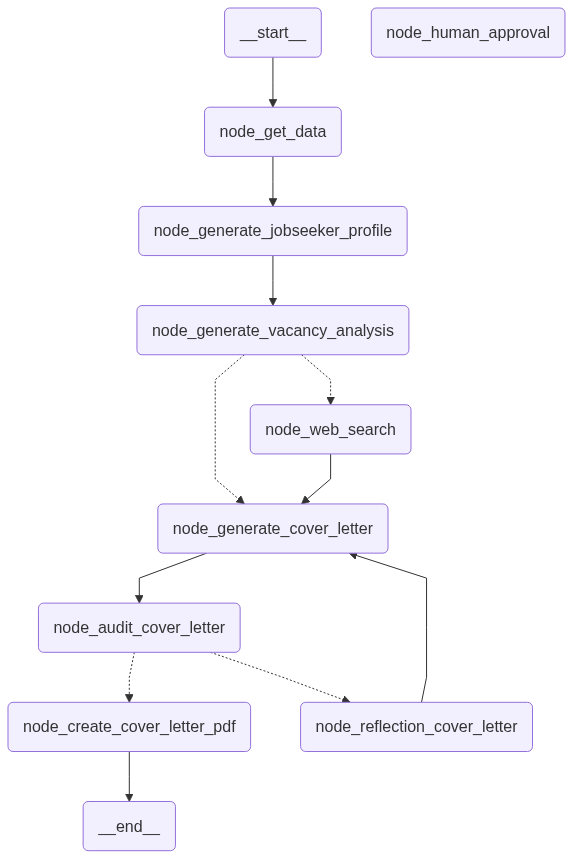

In [16]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Routing logic
def decide_company_found(state: dict) -> str:
    company = state.get("company_name")
    
    if company and company.strip() or company is None:
        # Company name is non-empty and not just whitespace
        return "node_web_search"
    else:
        # Company name is missing or empty
        return "node_generate_cover_letter"


# Update editorial decision logic to point to the new regenerate node
def decide_editorial_next(state: testState) -> str:
    """
    Decide whether to trigger a reflection round or proceed to human review.

    - If there are editorial violations AND we haven't hit the max retry limit → Reflect again.
    - Otherwise → move to human approval.
    """
    has_violations: bool = bool(state.get("editorial_violations_log"))
    current_iteration: int = state.get("iterations", 0)
    max_iterations: int = state.get("max_iterations", 2)

    print(f"iteration: {current_iteration}, has violations: {has_violations}, max iterations: {max_iterations}\n")

    if has_violations and current_iteration < max_iterations:
        return "node_reflection_cover_letter"
    return "node_create_cover_letter_pdf"

    
# Human loop routing remains unchanged
def decide_human_next(state):
    return "node_audit_cover_letter" if state.get("human_review_needed") else "node_create_cover_letter_pdf"


# Build graph
builder = StateGraph(testState)
builder.add_node("node_get_data", node_get_data) ## builder.add_node("semantic_similarity", semantic_similarity)
builder.add_node("node_generate_jobseeker_profile", node_generate_jobseeker_profile)
builder.add_node("node_generate_vacancy_analysis", node_generate_vacancy_analysis)
builder.add_node("node_web_search", node_web_search)
builder.add_node("node_generate_cover_letter", node_generate_cover_letter)
builder.add_node("node_reflection_cover_letter", node_reflection_cover_letter)
builder.add_node("node_audit_cover_letter", node_audit_cover_letter)
builder.add_node("node_human_approval", node_human_approval)
builder.add_node("node_create_cover_letter_pdf", node_create_cover_letter_pdf)

# build flow

builder.set_entry_point("node_get_data")
builder.add_edge("node_get_data", "node_generate_jobseeker_profile")
builder.add_edge("node_generate_jobseeker_profile", "node_generate_vacancy_analysis")
builder.add_conditional_edges("node_generate_vacancy_analysis", decide_company_found, path_map={
    "node_web_search": "node_web_search",
    "node_generate_cover_letter": "node_generate_cover_letter"
})
builder.add_edge("node_web_search", "node_generate_cover_letter")
builder.add_edge("node_generate_cover_letter", "node_audit_cover_letter")

# Updated conditional path from editorial
builder.add_conditional_edges("node_audit_cover_letter", decide_editorial_next, path_map={
    "node_reflection_cover_letter": "node_reflection_cover_letter",
    "node_create_cover_letter_pdf": "node_create_cover_letter_pdf"
})
# Add the reflection path that loops back to generation
builder.add_edge("node_reflection_cover_letter", "node_generate_cover_letter")

# Human approval already decides where to go next via Command
# builder.add_edge("node_human_approval", "node_reflection_cover_letter")
# builder.add_conditional_edges("node_human_approval", decide_human_next, path_map={
#     "node_audit_cover_letter": "node_audit_cover_letter",
#     "node_create_cover_letter_pdf": "node_create_cover_letter_pdf"
# })
# builder.add_edge("node_human_approval", "node_create_cover_letter_pdf")

builder.set_finish_point("node_create_cover_letter_pdf")

# Compile + render
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:

from uuid import uuid4

unique_id = uuid4().hex[0:8]
from pprint import pprint
# thread_id = str(uuid.uuid4())
config = {
    "configurable": {
        # Checkpoints are accessed by thread_id
        "thread_id": unique_id,
    }
}

for output in graph.stream(initial_state, config=config, stream_mode='values'):
    # 
    pprint("output: {output}")
    # for key, value in output.items():
    #     if key == "messages":
    #         pprint(f" '{value}' ")

        
pprint("-------------TOTAL END----------------")

'output: {output}'
!!NODE!!: node_get_data.py - Starting unified data fetch

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
🔗 Connecting to Qdrant at http://cover_letter_qdrant:6333 with collection 'embedded_cover_letters'
✅ Collection already exists: embedded_cover_letters
DOCUMENT:Jannik M. B. Sørensen  Mail: Mangabat93@gmail.com   TLF-nr: +4526335065  
Flytter gerne så tæt på som muligt  Hej KOMBIT -teamet , 
Jeg er uddannet i Data Science (ICT) og har en professionsbachelor i Økonomi & IT, hvor 
jeg arbejdede med business maturity og strategiimplementering i digitaliseringsprojekter. 
Jeres ambition om at skabe sikre og værdiskabende AI -løsninger til kommunerne – både 
målbare, forståelige og ansvarlige – rammer noget, jeg selv har tænkt meget over.  
Motivation  
Det er sjældent, man ser en stilling, hvor det tekniske, for

TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'list'>

In [ ]:
output["cover_letter_revision_history"][0]

{'iteration': 0,
 'cover_letter_output': CoverLetterResult(company_name='Novo Nordisk', job_title='Project Manager', introduction="I hold a Master's degree in Data Science and have a strong background in IT and business strategy. My professional career has revolved around combining analytical problem-solving with project management, and I thrive in environments where collaboration and strategic implementation align to drive impactful progress.", motivation="Novo Nordisk's commitment to improving lives through innovative and sustainable solutions deeply resonates with my professional interests and values. Having worked on capacity improvements, cross-functional collaboration, and data-driven optimization, I see an opportunity to channel my skills towards ensuring operational excellence and sustainable growth within your aseptic manufacturing network.", unique_selling_points='My approach balances technical precision and an adaptable mindset, ensuring that all solutions are both impactful

In [ ]:
output['']

KeyError: ''